Create at least 5 visualizations for each dataset.

Possible charts:

- Bar Chart
- Histogram
- Pie Chart
- Line Chart
- Box Plot

Each visualization should include:

- Title
- Labels
- Short explanation of findings
  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"C:\Users\IT\Desktop\Data Analysis\AnalystLab Africa Internship\OnlineRetail.csv\cleaned_online_retail.csv",low_memory=False)
df

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,White Hanging Heart T-Light Holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,White Metal Lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,Red Woolly Hottie White Heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
524873,581587,22613,Pack Of 20 Spaceboy Napkins,12,2011-12-09 12:50:00,0.85,12680.0,France
524874,581587,22899,Children'S Apron Dolly Girl,6,2011-12-09 12:50:00,2.10,12680.0,France
524875,581587,23254,Childrens Cutlery Dolly Girl,4,2011-12-09 12:50:00,4.15,12680.0,France
524876,581587,23255,Childrens Cutlery Circus Parade,4,2011-12-09 12:50:00,4.15,12680.0,France


In [6]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

In [7]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False)
top_products.head(10)

description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        78033
World War 2 Gliders Asstd Designs     54951
Jumbo Bag Red Retrospot               48371
White Hanging Heart T-Light Holder    37872
Popcorn Holder                        36749
Pack Of 72 Retrospot Cake Cases       36396
Assorted Colour Bird Ornament         36362
Rabbit Night Light                    30739
Mini Paint Set Vintage                26633
Name: quantity, dtype: int64

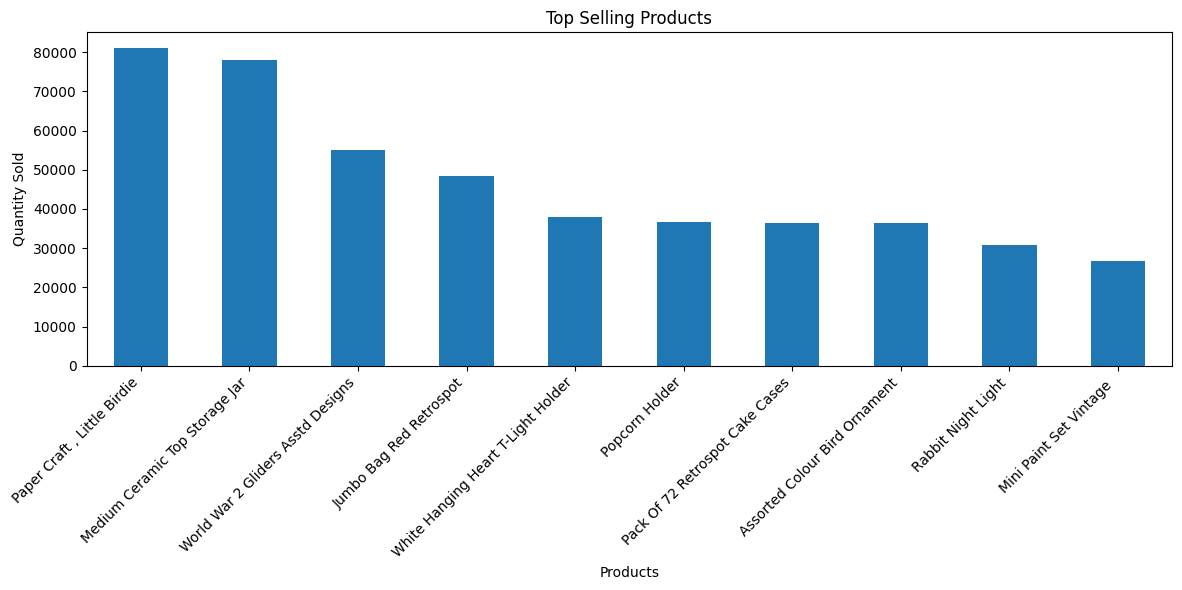

In [14]:
# Bar chart
# Top 10 products only (important)
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))  # make chart readable

top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.xlabel("Products")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45, ha='right')  # fix overlapping/dark labels
plt.tight_layout()  # adjust spacing

plt.show()

Findings:- Paper craft,Little Birdie selling(80995) is more than than total sales.

In [19]:
df['revenue']=df['quantity']*df['unitprice']
df['revenue']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
524873    10.20
524874    12.60
524875    16.60
524876    16.60
524877    14.85
Name: revenue, Length: 524878, dtype: float64

In [26]:
country_rev=df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)
country_rev


country
United Kingdom    9001744.094
Netherlands        285446.340
Eire               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64

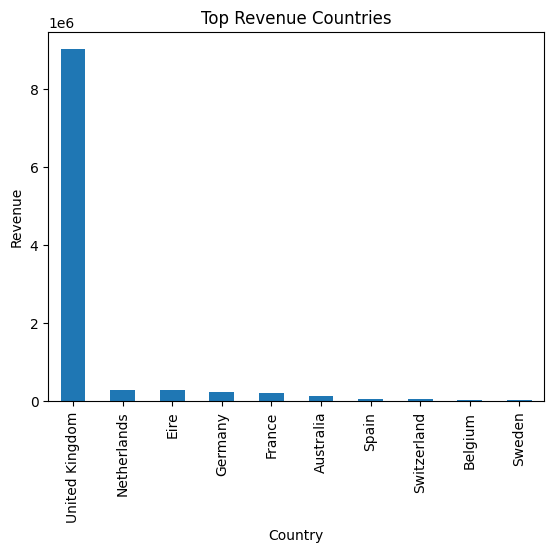

In [28]:
#Revenue BY country
country_rev.head(10).plot(kind='bar')

plt.title("Top Revenue Countries")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

Findings:-United Kingdom Generate most of the revenues

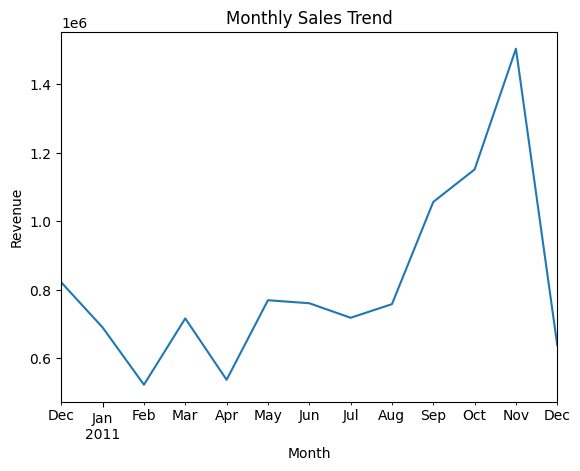

In [30]:


# Convert InvoiceDate to datetime if not already
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Create month column
df['month'] = df['invoicedate'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df.groupby('month')['revenue'].sum()

# Monthly Sales Trend
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Findings:-Sales increase during festive seasons.(During October and November)

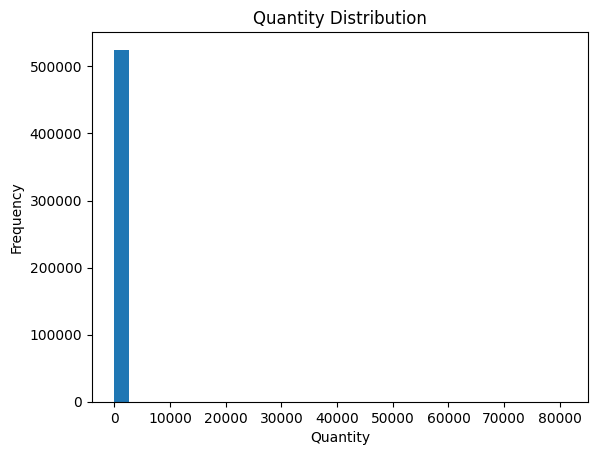

In [31]:
#Quantity Distribution
plt.hist(df['quantity'],bins=30)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Findings:-Most purchases are small quantities.

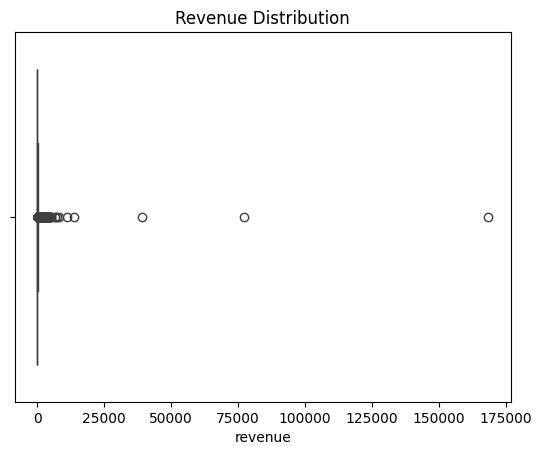

In [33]:
#Revenue Boxplot
import seaborn as sns
sns.boxplot(x=df['revenue'])

plt.title("Revenue Distribution")
plt.show()

Findings:-Revenue contains several high-value outliers.